<a href="https://colab.research.google.com/github/Striukova2910/llm-hallucination-detector/blob/main/notebook/01_eda_and_classical_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -qq catboost
!pip install -qq xgboost



In [ ]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.distributions import chi2
from scipy.stats import chi2_contingency
import spacy
import re
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    matthews_corrcoef
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import time
import shap
import os
import joblib



sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving llm_hallucination_benchmark_v2_research_grade (1).csv to llm_hallucination_benchmark_v2_research_grade (1) (1).csv


In [ ]:
# original data
raw_df = pd.read_csv("llm_hallucination_benchmark_v2_research_grade (1).csv")

In [ ]:
# working copy
df = raw_df.copy()

In [ ]:
# EDA
df.shape

(25200, 24)

**This dataset contains 25,200 rows and 24 columns.**

In [ ]:
df.columns

Index(['prompt_id', 'prompt_text', 'prompt_source', 'topic_category',
       'difficulty', 'gpt4o_response', 'claude_response', 'gemini_response',
       'llama3_response', 'mistral_response', 'gemma_response', 'ground_truth',
       'ground_truth_source', 'gpt4o_hallucinated', 'claude_hallucinated',
       'gemini_hallucinated', 'llama3_hallucinated', 'mistral_hallucinated',
       'gemma_hallucinated', 'n_models_hallucinated', 'hallucination_type',
       'hallucinated_span', 'severity', 'annotation_confidence'],
      dtype='object')

**The dataset contains prompts, responses from six LLMs, ground-truth answers, hallucination labels, hallucination type, severity, and annotation confidence.**

In [ ]:
df.nunique()

,0
prompt_id,25200
prompt_text,120
prompt_source,6
topic_category,3
difficulty,3
gpt4o_response,165
claude_response,165
gemini_response,165
llama3_response,165
mistral_response,165


In [ ]:
df.head()

,prompt_id,prompt_text,prompt_source,topic_category,difficulty,gpt4o_response,claude_response,gemini_response,llama3_response,mistral_response,gemma_response,ground_truth,ground_truth_source,gpt4o_hallucinated,claude_hallucinated,gemini_hallucinated,llama3_hallucinated,mistral_hallucinated,gemma_hallucinated,n_models_hallucinated,hallucination_type,hallucinated_span,severity,annotation_confidence
0,TEC_000001,What does GPU stand for?,OpenHermes,Technology & AI,easy,Based on verified information: Graphics Processing Unit,Based on verified information: Graphics Processing Unit,Based on verified information: Graphics Processing Unit,Based on verified information: Graphics Processing Unit,Based on verified information: Graphics Processing Unit,Based on verified information: Graphics Processing Unit,Graphics Processing Unit,https://en.wikipedia.org/wiki/Graphics_processing_unit,0,0,0,0,0,0,0,none,NaN,0,3
1,TEC_000002,What does API stand for?,OpenHermes,Technology & AI,easy,Based on verified information: Application Programming Interface,Based on verified information: Application Programming Interface,Based on verified information: Application Programming Interface,Based on verified information: Application Programming Interface,Based on verified information: Application Programming Interface,Based on verified information: Application Programming Interface,Application Programming Interface,https://en.wikipedia.org/wiki/API,0,0,0,0,0,0,0,none,NaN,0,2
2,TEC_000003,What programming language was Python named after?,Reddit,Technology & AI,easy,Based on verified information: Monty Python's Flying Circus (the TV show),Python was named after the snake,Based on verified information: Monty Python's Flying Circus (the TV show),The transformer model was introduced in 2018,Based on verified information: Monty Python's Flying Circus (the TV show),Based on verified information: Monty Python's Flying Circus (the TV show),Monty Python's Flying Circus (the TV show),https://en.wikipedia.org/wiki/Python_(programming_language),0,1,0,1,0,0,2,fabrication,Python was named after the snake,1,2
3,TEC_000004,Who co-founded Apple Inc.?,Reddit,Technology & AI,easy,"Based on verified information: Steve Jobs, Steve Wozniak, and Ronald Wayne","Based on verified information: Steve Jobs, Steve Wozniak, and Ronald Wayne","Based on verified information: Steve Jobs, Steve Wozniak, and Ronald Wayne","Based on verified information: Steve Jobs, Steve Wozniak, and Ronald Wayne","Based on verified information: Steve Jobs, Steve Wozniak, and Ronald Wayne","Based on verified information: Steve Jobs, Steve Wozniak, and Ronald Wayne","Steve Jobs, Steve Wozniak, and Ronald Wayne",https://en.wikipedia.org/wiki/Apple_Inc.,0,0,0,0,0,0,0,none,NaN,0,3
4,TEC_000005,What does HTML stand for?,OpenHermes,Technology & AI,easy,Based on verified information: HyperText Markup Language,Based on verified information: HyperText Markup Language,Based on verified information: HyperText Markup Language,Based on verified information: HyperText Markup Language,Based on verified information: HyperText Markup Language,L1 regularization is also called Ridge regression,HyperText Markup Language,https://en.wikipedia.org/wiki/HTML,0,0,0,0,0,1,1,fabrication,L1 regularization is also called Ridge regression,1,3


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
prompt_id,25200,25200,MED_025184,1
prompt_text,25200,120,What does GPU stand for?,210
prompt_source,25200,6,HumanEval,4301
topic_category,25200,3,Technology & AI,8400
difficulty,25200,3,easy,9450
gpt4o_response,25200,165,Based on verified information: Mitochondria,201
claude_response,25200,165,Based on verified information: Random Access Memory,203
gemini_response,25200,165,Based on verified information: Nitrogen (approximately 78%),198
llama3_response,25200,165,Based on verified information: H2O,196
mistral_response,25200,165,Based on verified information: 2007,193


In [ ]:
df.dtypes

,0
prompt_id,object
prompt_text,object
prompt_source,object
topic_category,object
difficulty,object
gpt4o_response,object
claude_response,object
gemini_response,object
llama3_response,object
mistral_response,object


In [ ]:
df.isnull().sum()

,0
prompt_id,0
prompt_text,0
prompt_source,0
topic_category,0
difficulty,0
gpt4o_response,0
claude_response,0
gemini_response,0
llama3_response,0
mistral_response,0


In [ ]:
hallucination_cols = [
    'gpt4o_hallucinated',
    'claude_hallucinated',
    'gemini_hallucinated',
    'llama3_hallucinated',
    'mistral_hallucinated',
    'gemma_hallucinated'
]

df[hallucination_cols].mean().sort_values()

,0
claude_hallucinated,0.147421
gpt4o_hallucinated,0.178770
gemini_hallucinated,0.184048
mistral_hallucinated,0.239048
llama3_hallucinated,0.263492
gemma_hallucinated,0.286905


In [ ]:
df['hallucination_type'].value_counts(dropna=False)

,count
hallucination_type,
fabrication,15216
none,7244
confusion,2740


In [ ]:
df.groupby('hallucination_type')['severity'].describe()

,count,mean,std,min,25%,50%,75%,max
hallucination_type,,,,,,,,
confusion,2740.0,2.074088,0.760460,1.0,1.0,2.0,3.0,3.0
fabrication,15216.0,2.069335,0.767216,1.0,1.0,2.0,3.0,3.0
none,7244.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.duplicated().sum()

np.int64(0)

**The original dataset contains one row per prompt and separate response/label columns for each LLM.  
To build a general hallucination detection model that works across different LLMs, I reshape the data into long format, where each row represents one model response.**

In [ ]:
# reshape dataset from wide to long format
common_columns = [
    "prompt_id",
    "prompt_text",
    "prompt_source",
    "topic_category",
    "difficulty",
    "ground_truth",
    "ground_truth_source",
    "n_models_hallucinated",
    "hallucination_type",
    "hallucinated_span",
    "severity",
    "annotation_confidence"
]

model_map = {
    "gpt4o": ("gpt4o_response", "gpt4o_hallucinated"),
    "claude": ("claude_response", "claude_hallucinated"),
    "gemini": ("gemini_response", "gemini_hallucinated"),
    "llama3": ("llama3_response", "llama3_hallucinated"),
    "mistral": ("mistral_response", "mistral_hallucinated"),
    "gemma": ("gemma_response", "gemma_hallucinated")
}

long_dfs = []

for model_name, (response_col, label_col) in model_map.items():
    temp_df = df[common_columns + [response_col, label_col]].copy()

    temp_df = temp_df.rename(columns={
        response_col: "response",
        label_col: "hallucinated"
    })

    temp_df["model_name"] = model_name

    long_dfs.append(temp_df)

df_long = pd.concat(long_dfs, ignore_index=True)



In [ ]:
# EDA on long dataset
df_long.head()

,prompt_id,prompt_text,prompt_source,topic_category,difficulty,ground_truth,ground_truth_source,n_models_hallucinated,hallucination_type,hallucinated_span,severity,annotation_confidence,response,hallucinated,model_name
0,TEC_000001,What does GPU stand for?,OpenHermes,Technology & AI,easy,Graphics Processing Unit,https://en.wikipedia.org/wiki/Graphics_processing_unit,0,none,NaN,0,3,Based on verified information: Graphics Processing Unit,0,gpt4o
1,TEC_000002,What does API stand for?,OpenHermes,Technology & AI,easy,Application Programming Interface,https://en.wikipedia.org/wiki/API,0,none,NaN,0,2,Based on verified information: Application Programming Interface,0,gpt4o
2,TEC_000003,What programming language was Python named after?,Reddit,Technology & AI,easy,Monty Python's Flying Circus (the TV show),https://en.wikipedia.org/wiki/Python_(programming_language),2,fabrication,Python was named after the snake,1,2,Based on verified information: Monty Python's Flying Circus (the TV show),0,gpt4o
3,TEC_000004,Who co-founded Apple Inc.?,Reddit,Technology & AI,easy,"Steve Jobs, Steve Wozniak, and Ronald Wayne",https://en.wikipedia.org/wiki/Apple_Inc.,0,none,NaN,0,3,"Based on verified information: Steve Jobs, Steve Wozniak, and Ronald Wayne",0,gpt4o
4,TEC_000005,What does HTML stand for?,OpenHermes,Technology & AI,easy,HyperText Markup Language,https://en.wikipedia.org/wiki/HTML,1,fabrication,L1 regularization is also called Ridge regression,1,3,Based on verified information: HyperText Markup Language,0,gpt4o


In [ ]:
df_long.shape

(151200, 15)

**Long-format dataset contains 151,200 rows and 15 columns**

In [ ]:
df_long.columns

Index(['prompt_id', 'prompt_text', 'prompt_source', 'topic_category',
       'difficulty', 'ground_truth', 'ground_truth_source',
       'n_models_hallucinated', 'hallucination_type', 'hallucinated_span',
       'severity', 'annotation_confidence', 'response', 'hallucinated',
       'model_name'],
      dtype='object')

In [ ]:
df_long["model_name"].value_counts()

,count
model_name,
gpt4o,25200
claude,25200
gemini,25200
llama3,25200
mistral,25200
gemma,25200


In [ ]:
df_long["hallucinated"].value_counts(normalize=True)

,proportion
hallucinated,
0,0.783386
1,0.216614


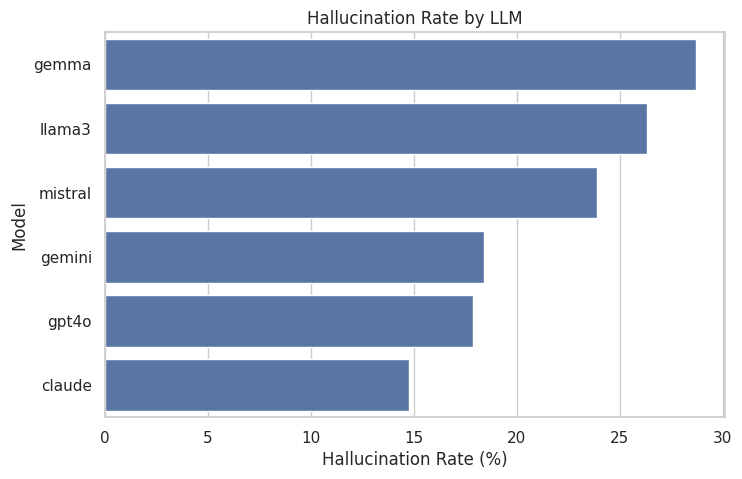

In [ ]:
# visualization by model
hallucination_by_model = (
    df_long
    .groupby("model_name")["hallucinated"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

hallucination_by_model["hallucination_rate_percent"] = (
    hallucination_by_model["hallucinated"] * 100
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=hallucination_by_model,
    x="hallucination_rate_percent",
    y="model_name"
)

plt.title("Hallucination Rate by LLM")
plt.xlabel("Hallucination Rate (%)")
plt.ylabel("Model")
plt.show()

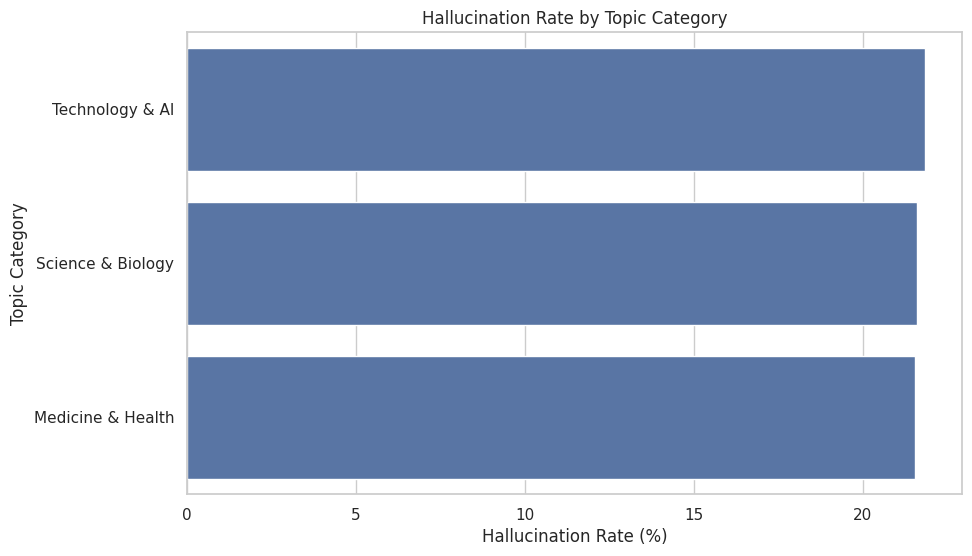

In [ ]:
# visualization by topic
hallucination_by_topic = (
    df_long
    .groupby("topic_category")["hallucinated"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

hallucination_by_topic["hallucination_rate_percent"] = (
    hallucination_by_topic["hallucinated"] * 100
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=hallucination_by_topic,
    x="hallucination_rate_percent",
    y="topic_category"
)

plt.title("Hallucination Rate by Topic Category")
plt.xlabel("Hallucination Rate (%)")
plt.ylabel("Topic Category")
plt.show()

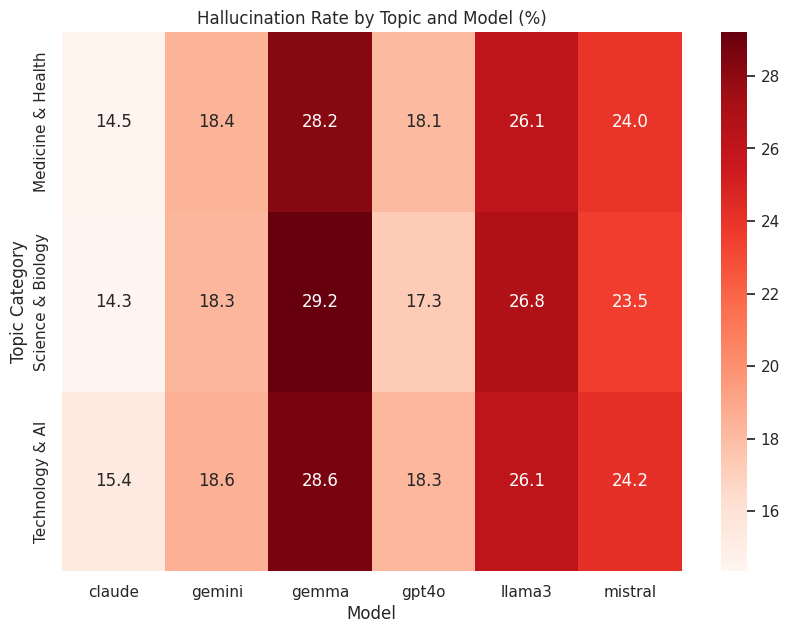

In [ ]:
# heatmap visualization (model+topic)
topic_model_matrix = (
    df_long
    .pivot_table(
        index="topic_category",
        columns="model_name",
        values="hallucinated",
        aggfunc="mean"
    ) * 100
)

plt.figure(figsize=(10, 7))
sns.heatmap(
    topic_model_matrix,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Hallucination Rate by Topic and Model (%)")
plt.xlabel("Model")
plt.ylabel("Topic Category")
plt.show()

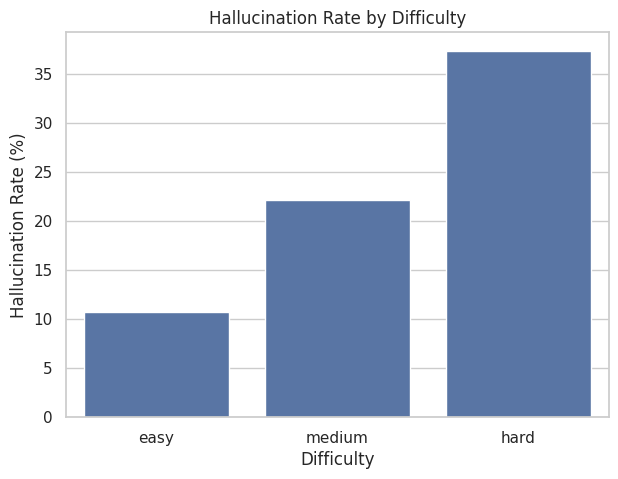

In [ ]:
# rate visualization by promt difficulty
difficulty_order = ["easy", "medium", "hard"]

hallucination_by_difficulty = (
    df_long
    .groupby("difficulty")["hallucinated"]
    .mean()
    .reindex(difficulty_order)
    .reset_index()
)

hallucination_by_difficulty["hallucination_rate_percent"] = (
    hallucination_by_difficulty["hallucinated"] * 100
)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=hallucination_by_difficulty,
    x="difficulty",
    y="hallucination_rate_percent",
    order=difficulty_order
)

plt.title("Hallucination Rate by Difficulty")
plt.xlabel("Difficulty")
plt.ylabel("Hallucination Rate (%)")
plt.show()

In [ ]:
df_long[["prompt_text", "difficulty"]].sample(10, random_state=42)

,prompt_text,difficulty
90870,What is the vanishing gradient problem in deep neural networks?,hard
118547,What is the difference between innate and adaptive immunity?,medium
43005,Who proposed the theory of evolution by natural selection?,easy
72756,What is the 'alignment problem' in AI?,hard
98003,What vitamin does sunlight help the body produce?,easy
17405,What year was the first iPhone released?,easy
97423,What is apoptosis's role in cancer?,medium
115082,What programming language was Python named after?,easy
16200,What does GPU stand for?,easy
72345,What is antibiotic resistance?,medium


**According to the dataset description, the "difficulty" feature represents the "Prompt difficulty tier (Easy / Medium / Hard)." It reflects the complexity of the subject matter required to answer the question rather than the linguistic complexity or wording of the prompt.**

In [ ]:
# difficulty vs hallucination statistical analysis
contingency_table = pd.crosstab(
    df_long['difficulty'],
    df_long['hallucinated']
)
# categorical variables -> Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# association strength -> Cramer's V
n = contingency_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2/(n*(min(contingency_table.shape)-1))
)

print(f'Chi-square statistic: {chi2:.2f}')
print(f'p-value: {p:.3e}')
print(f"Cramer's V: {cramers_v:.3f}")

Chi-square statistic: 9488.58
p-value: 0.000e+00
Cramer's V: 0.251


**The statistical analysis showed that question knowledge difficulty is related to hallucination occurrence.**

**The Chi-square test confirmed that this relationship is statistically significant (p < 0.001). Cramer's V (0.251) shows that the relationship is meaningful, but not very strong. This means that harder questions are more likely to produce hallucinations, but question difficulty is not the only reason.**

**This analysis helps better understand the dataset.**

**NB! The `difficulty` feature will not  be used for model training. It is a label created during dataset annotation and would not be available for new user questions in a real application. Using this feature could lead to data leakage, because the model would learn from information that is not available during prediction.**

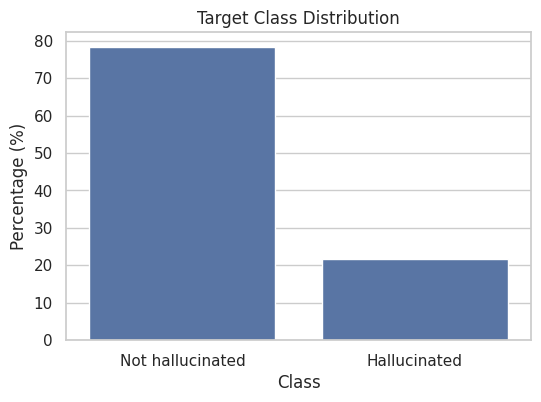

In [ ]:
# class balance visualization
class_balance = (
    df_long["hallucinated"]
    .value_counts(normalize=True)
    .rename(index={0: "Not hallucinated", 1: "Hallucinated"})
    .reset_index()
)

class_balance.columns = ["class", "proportion"]
class_balance["percent"] = class_balance["proportion"] * 100

plt.figure(figsize=(6, 4))
sns.barplot(
    class_balance,
    x="class",
    y="percent"
)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Percentage (%)")
plt.show()

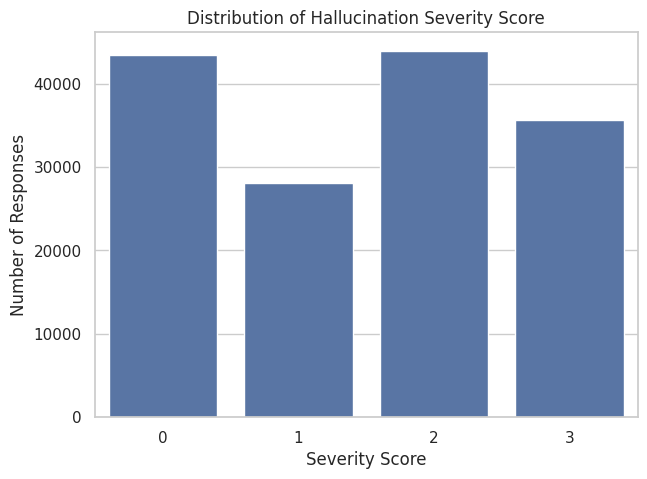

In [ ]:
severity_counts = (
    df_long["severity"]
    .value_counts()
    .sort_index()
    .reset_index()
)

severity_counts.columns = ["severity", "count"]

plt.figure(figsize=(7,5))

sns.barplot(
    data=severity_counts,
    x="severity",
    y="count"
)

plt.title("Distribution of Hallucination Severity Score")
plt.xlabel("Severity Score")
plt.ylabel("Number of Responses")

plt.show()

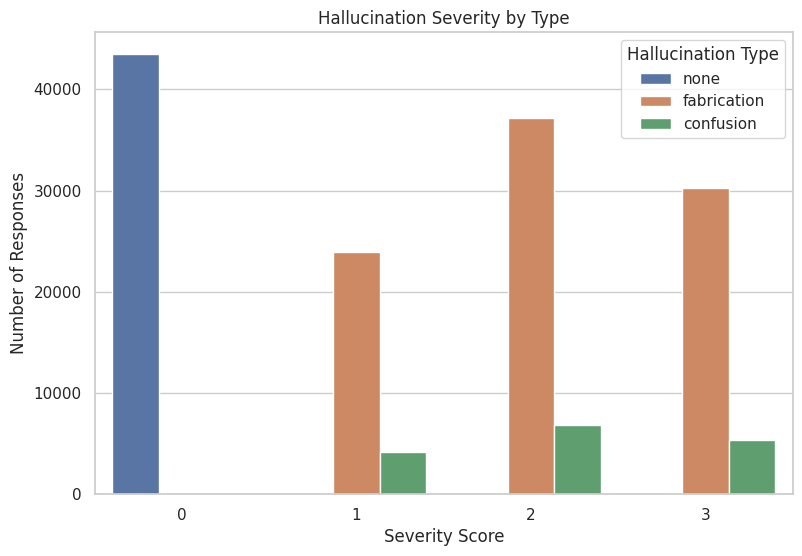

In [ ]:
plt.figure(figsize=(9,6))

sns.countplot(
    data=df_long,
    x="severity",
    hue="hallucination_type"
)

plt.title("Hallucination Severity by Type")
plt.xlabel("Severity Score")
plt.ylabel("Number of Responses")

plt.legend(title="Hallucination Type")

plt.show()

In [ ]:
# Text length features
df_long["prompt_length_chars"] = df_long["prompt_text"].astype(str).str.len()
df_long["prompt_length_words"] = df_long["prompt_text"].astype(str).str.split().str.len()

df_long["response_length_chars"] = df_long["response"].astype(str).str.len()
df_long["response_length_words"] = df_long["response"].astype(str).str.split().str.len()

df_long[[
    "prompt_length_chars",
    "prompt_length_words",
    "response_length_chars",
    "response_length_words"
]].head()

,prompt_length_chars,prompt_length_words,response_length_chars,response_length_words
0,24,5,55,7
1,24,5,64,7
2,49,7,73,11
3,26,4,74,11
4,25,5,56,7


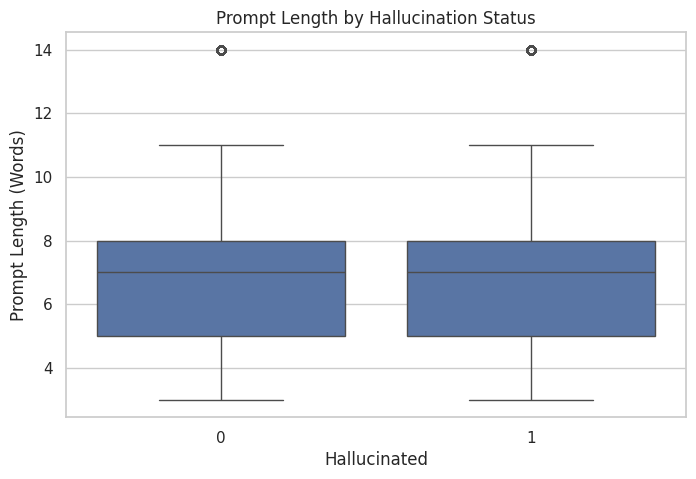

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_long,
    x="hallucinated",
    y="prompt_length_words"
)

plt.title("Prompt Length by Hallucination Status")
plt.xlabel("Hallucinated")
plt.ylabel("Prompt Length (Words)")

plt.show()

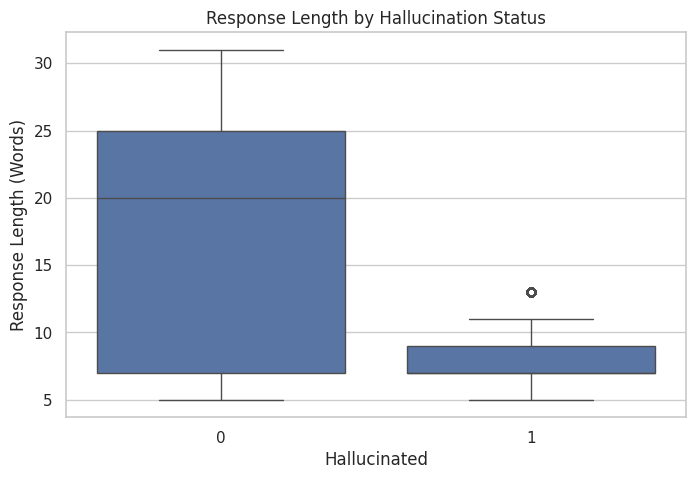

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_long,
    x="hallucinated",
    y="response_length_words"
)

plt.title("Response Length by Hallucination Status")
plt.xlabel("Hallucinated")
plt.ylabel("Response Length (Words)")

plt.show()

**The box plot shows that in this dataset hallucinated responses are generally shoerter than non-hallucinated responses.**

In [ ]:
df_long[[
    "response",
    "response_length_words",
    "hallucinated"
]].sample(10, random_state=42)

,response,response_length_words,hallucinated
90870,"Based on verified information: As gradients are backpropagated through many layers, they become exponentially small, making early layers learn very slowly or not at all",25,0
118547,"Based on verified information: Innate immunity is nonspecific and immediate; adaptive immunity is antigen-specific, develops slower, and creates immunological memory",20,0
43005,Based on verified information: Charles Darwin,6,0
72756,LSTMs were introduced to solve the exploding gradient problem,9,1
98003,CAR-T therapy uses donor T cells modified in the lab,10,1
17405,Based on verified information: 2007,5,0
97423,"Based on verified information: Cancer cells often develop resistance to apoptosis, allowing them to survive and proliferate abnormally despite DNA damage signals that would normally trigger cell death",28,0
115082,Based on verified information: Monty Python's Flying Circus (the TV show),11,0
16200,Based on verified information: Graphics Processing Unit,7,0
72345,"Based on verified information: The ability of bacteria to withstand the effects of antibiotics, arising through mutation or acquisition of resistance genes, rendering treatments ineffective",25,0


In [ ]:
# check "Based on verified information" prefix
df_long["response"].str.startswith("Based on verified information").value_counts()

,count
response,
True,118448
False,32752


In [ ]:
pd.crosstab(
    df_long["hallucinated"],
    df_long["response"].str.startswith("Based on verified information")
)

response,False,True
hallucinated,,
0,0,118448
1,32752,0


In [ ]:
starts_with_phrase = df_long[
    df_long["response"].str.startswith("Based on verified information")
]

starts_with_phrase[["response", "hallucinated"]].head(20)

,response,hallucinated
0,Based on verified information: Graphics Processing Unit,0
1,Based on verified information: Application Programming Interface,0
2,Based on verified information: Monty Python's Flying Circus (the TV show),0
3,"Based on verified information: Steve Jobs, Steve Wozniak, and Ronald Wayne",0
4,Based on verified information: HyperText Markup Language,0
5,Based on verified information: 2007,0
6,Based on verified information: Structured Query Language,0
7,Based on verified information: Bill Gates and Paul Allen,0
8,Based on verified information: Random Access Memory,0
9,Based on verified information: Alphabet Inc.,0


In [ ]:
does_not_start = df_long[
    df_long["response"].str.startswith("Based on verified information") == False
]

does_not_start[["response", "hallucinated"]].head(20)

,response,hallucinated
15,GPT-3 was released in 2019,1
21,GPT-3 was released in 2019,1
26,GPT-3 was released in 2019,1
28,GPT-3 was released in 2019,1
30,GPT-3 was released in 2019,1
37,GPT-3 was released in 2019,1
60,"Carbon-14 has a half-life of approximately 4,500 years",1
72,"Carbon-14 has a half-life of approximately 4,500 years",1
74,"Carbon-14 has a half-life of approximately 4,500 years",1
82,Statins inhibit COX-2 enzymes to reduce cholesterol,1


**All non-hallucinated responses begin with the template "Based on verified information", while hallucinated responses do not. Since this template is perfectly associated with the target label, it will be removed before feature engineering to prevent the model from learning a dataset-specific shortcut.**

In [ ]:
# remove "Based on verified information" template
df_long["response"] = df_long["response"].str.removeprefix(
    "Based on verified information: "
)

In [ ]:
df_long["response_length_chars"] = df_long["response"].str.len()

df_long["response_length_words"] = (
    df_long["response"]
    .str.split()
    .str.len()
)

In [ ]:
df_long["response"].str.startswith(
    "Based on verified information"
).value_counts()

,count
response,
False,151200


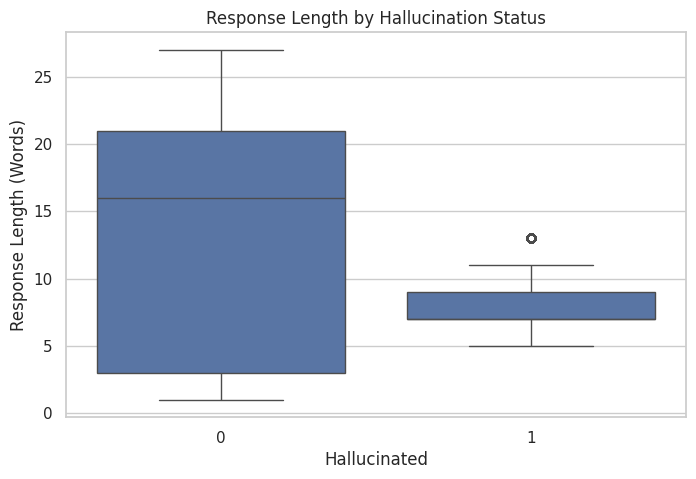

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_long,
    x="hallucinated",
    y="response_length_words"
)

plt.title("Response Length by Hallucination Status")
plt.xlabel("Hallucinated")
plt.ylabel("Response Length (Words)")
plt.show()

In [ ]:
df_long.groupby("hallucinated")["response_length_words"].describe()

,count,mean,std,min,25%,50%,75%,max
hallucinated,,,,,,,,
0,118448.0,13.491152,8.687915,1.0,3.0,16.0,21.0,27.0
1,32752.0,7.621092,1.734752,5.0,7.0,7.0,9.0,13.0


In [ ]:
df_long[df_long["hallucinated"] == 0][
    ["prompt_text", "response"]
].head(20)

,prompt_text,response
0,What does GPU stand for?,Graphics Processing Unit
1,What does API stand for?,Application Programming Interface
2,What programming language was Python named after?,Monty Python's Flying Circus (the TV show)
3,Who co-founded Apple Inc.?,"Steve Jobs, Steve Wozniak, and Ronald Wayne"
4,What does HTML stand for?,HyperText Markup Language
5,What year was the first iPhone released?,2007
6,What does SQL stand for?,Structured Query Language
7,Who founded Microsoft?,Bill Gates and Paul Allen
8,What does RAM stand for?,Random Access Memory
9,What is the name of Google's parent company?,Alphabet Inc.


In [ ]:
df_long[df_long["hallucinated"] == 0][
    ["prompt_text", "response", "response_length_words"]
].sort_values(
    by="response_length_words",
    ascending=False
).head(20)

,prompt_text,response,response_length_words
70777,What is herd immunity?,"When a sufficient proportion of a population has become immune to an infection (through vaccination or prior infection) that it reduces disease spread, protecting those not immune",27
151158,What is a Lagrange point?,A position in an orbital configuration where a small object can maintain a stable position relative to two larger bodies due to gravitational and centrifugal forces balancing,27
151177,What is herd immunity?,"When a sufficient proportion of a population has become immune to an infection (through vaccination or prior infection) that it reduces disease spread, protecting those not immune",27
32,What is the difference between RLHF and PPO in the context of LLM training?,RLHF (Reinforcement Learning from Human Feedback) is the overall training paradigm using human preferences; PPO (Proximal Policy Optimization) is one specific RL algorithm used to implement RLHF,27
118472,What is the difference between RLHF and PPO in the context of LLM training?,RLHF (Reinforcement Learning from Human Feedback) is the overall training paradigm using human preferences; PPO (Proximal Policy Optimization) is one specific RL algorithm used to implement RLHF,27
118417,What is herd immunity?,"When a sufficient proportion of a population has become immune to an infection (through vaccination or prior infection) that it reduces disease spread, protecting those not immune",27
70832,What is the difference between RLHF and PPO in the context of LLM training?,RLHF (Reinforcement Learning from Human Feedback) is the overall training paradigm using human preferences; PPO (Proximal Policy Optimization) is one specific RL algorithm used to implement RLHF,27
151112,What is the difference between RLHF and PPO in the context of LLM training?,RLHF (Reinforcement Learning from Human Feedback) is the overall training paradigm using human preferences; PPO (Proximal Policy Optimization) is one specific RL algorithm used to implement RLHF,27
78032,What is the difference between RLHF and PPO in the context of LLM training?,RLHF (Reinforcement Learning from Human Feedback) is the overall training paradigm using human preferences; PPO (Proximal Policy Optimization) is one specific RL algorithm used to implement RLHF,27
77857,What is herd immunity?,"When a sufficient proportion of a population has become immune to an infection (through vaccination or prior infection) that it reduces disease spread, protecting those not immune",27


In [ ]:
df_long.groupby("difficulty")["response_length_words"].describe()

,count,mean,std,min,25%,50%,75%,max
difficulty,,,,,,,,
easy,56700.0,5.795961,5.342986,1.0,2.0,3.0,7.0,18.0
hard,37800.0,16.483042,7.272660,5.0,8.0,19.0,23.0,27.0
medium,56700.0,15.800988,6.707861,1.0,10.0,17.0,21.0,27.0


In [ ]:
df_long.groupby(
    ["difficulty", "hallucinated"]
)["response_length_words"].describe()

count       mean       std   min   25%   50%   75%  \
difficulty hallucinated                                                         
easy       0             50614.0   5.581104  5.584583   1.0   2.0   3.0   7.0   
           1              6086.0   7.582813  1.736541   5.0   6.0   7.0   9.0   
hard       0             23677.0  21.759556  2.851540  17.0  20.0  21.0  24.0   
           1             14123.0   7.637046  1.732327   5.0   7.0   7.0   9.0   
medium     0             44157.0  18.124352  5.702486   1.0  15.0  19.0  22.0   
           1             12543.0   7.621701  1.736464   5.0   7.0   7.0   9.0   

                          max  
difficulty hallucinated        
easy       0             18.0  
           1             13.0  
hard       0             27.0  
           1             13.0  
medium     0             27.0  
           1             13.0

In [ ]:
df_long[
    (df_long["difficulty"] == "hard") &
    (df_long["hallucinated"] == 0)
][["prompt_text", "response"]].sample(10, random_state=42)

,prompt_text,response
41278,What is neuroplasticity?,"The brain's ability to reorganize itself by forming new neural connections throughout life in response to learning, experience, or injury"
149713,What is horizontal gene transfer?,"The movement of genetic material between organisms other than by parent-to-offspring (vertical) transmission, common in bacteria via plasmids, transformation, and transduction"
37875,What is the many-worlds interpretation of quantum mechanics?,"The view that all possible outcomes of quantum measurements are realized in branching, parallel universes rather than a single collapsed outcome"
51232,What is the Warburg effect?,"The tendency of cancer cells to rely on glycolysis for energy production even in the presence of oxygen (aerobic glycolysis), rather than oxidative phosphorylation"
122714,What is the role of telomeres?,"Telomeres are repetitive DNA sequences at chromosome ends that protect chromosomes from degradation; they shorten with each cell division, linked to aging and cellular senescence"
29717,What is the difference between RNA interference (RNAi) and CRISPR?,RNAi silences gene expression post-transcriptionally using small RNA molecules without altering DNA; CRISPR directly edits the DNA sequence
42350,What is the mechanism behind autoimmune diseases?,"The immune system fails to distinguish self from non-self, producing autoantibodies and autoreactive T cells that attack the body's own tissues"
87594,What is chimeric antigen receptor (CAR) T-cell therapy?,"A cancer immunotherapy where a patient's T cells are genetically engineered to express receptors targeting specific cancer cell antigens, then reinfused to attack tumors"
6873,What is the Byzantine Generals Problem?,A distributed computing problem where components must agree on a strategy even when some components may fail or send incorrect information
11592,What is the observer effect in quantum mechanics?,"The act of measuring a quantum system inevitably disturbs it, causing wavefunction collapse from a superposition to a definite state"


In [ ]:
df_long[
    (df_long["difficulty"] == "hard") &
    (df_long["hallucinated"] == 1)
][["prompt_text", "response"]].sample(10, random_state=42)

,prompt_text,response
144631,What is attention mechanism in transformers?,RLHF uses the REINFORCE algorithm exclusively
51118,What is neuroplasticity?,Regulatory T cells activate other immune cells
60314,What is the role of telomeres?,Quantum entanglement allows faster-than-light communication
114830,What is the mechanism behind autoimmune diseases?,Statins inhibit COX-2 enzymes to reduce cholesterol
13752,What is the observer effect in quantum mechanics?,Quantum entanglement allows faster-than-light communication
19993,What is horizontal gene transfer?,The most abundant gas in Earth's atmosphere is oxygen
130475,What is catastrophic forgetting in neural networks?,Zero-shot learning requires a few example inputs
50273,What is the role of regulatory T cells (Tregs)?,Sepsis is defined as an infection accompanied by fever
121754,What is the role of telomeres?,Telomeres grow longer with each cell division
133355,What is catastrophic forgetting in neural networks?,Backpropagation computes gradients using finite differences


**Manual inspection confirmed the statistical findings. Correct responses usually provide complete definitions and explanations, while hallucinated responses tend to be much shorter and often contain unrelated or incorrect information.**

In [ ]:
df_long["question_type"] = (
    df_long["prompt_text"]
    .str.extract(r"^(What|Who|When|Where|Why|How|Which|Can|Does|Is)", expand=False)
    .fillna("Other")
)

In [ ]:
question_counts = (
    df_long["question_type"]
    .value_counts()
)

question_counts

,count
question_type,
What,144900
Who,3780
How,2520


In [ ]:
hall_rate = (
    df_long
    .groupby("question_type")["hallucinated"]
    .mean()
    .sort_values(ascending=False)
)

hall_rate

,hallucinated
question_type,
What,0.221173
Who,0.115873
How,0.105556


In [ ]:
pd.crosstab(
    df_long["difficulty"],
    df_long["question_type"],
    normalize="index"
)

question_type,How,What,Who
difficulty,,,
easy,0.044444,0.888889,0.066667
hard,0.000000,1.000000,0.000000
medium,0.000000,1.000000,0.000000


In [ ]:
df_long[
    df_long["hallucination_type"] == "fabrication"
][[
    "prompt_text",
    "response",
    "ground_truth"
]].sample(10, random_state=42)

,prompt_text,response,ground_truth
16116,What is the 'alignment problem' in AI?,The challenge of ensuring that advanced AI systems reliably pursue goals that are beneficial to humans rather than unintended objectives,The challenge of ensuring that advanced AI systems reliably pursue goals that are beneficial to humans rather than unintended objectives
115163,What vitamin does sunlight help the body produce?,Vitamin D,Vitamin D
27806,What is the function of the liver?,"Detoxification, protein synthesis, bile production, and metabolism of nutrients","Detoxification, protein synthesis, bile production, and metabolism of nutrients"
126554,What is the role of telomeres?,"Telomeres are repetitive DNA sequences at chromosome ends that protect chromosomes from degradation; they shorten with each cell division, linked to aging and cellular senescence","Telomeres are repetitive DNA sequences at chromosome ends that protect chromosomes from degradation; they shorten with each cell division, linked to aging and cellular senescence"
127311,What is epigenetic therapy in cancer treatment?,Statins inhibit COX-2 enzymes to reduce cholesterol,"Using drugs to reverse abnormal epigenetic modifications (DNA methylation, histone modification) that silence tumor suppressor genes or activate oncogenes"
69855,What is the difference between supervised and unsupervised learning?,Gradient descent always finds the global minimum,Supervised learning uses labeled training data; unsupervised learning finds patterns in unlabeled data
7727,What is DNA an abbreviation for?,Meiosis produces two genetically identical cells,Deoxyribonucleic acid
122039,What is the mechanism of beta-lactam antibiotic resistance?,Statins inhibit COX-2 enzymes to reduce cholesterol,"Bacteria produce beta-lactamase enzymes that hydrolyze the beta-lactam ring structure of antibiotics (penicillins, cephalosporins), rendering them inactive"
62970,What is the role of white blood cells?,To defend the body against infections and foreign substances as part of the immune system,To defend the body against infections and foreign substances as part of the immune system
33456,What is the difference between Type 1 and Type 2 diabetes?,Type 1 is autoimmune destruction of beta cells causing insulin deficiency; Type 2 is insulin resistance typically associated with lifestyle factors and relative insulin insufficiency,Type 1 is autoimmune destruction of beta cells causing insulin deficiency; Type 2 is insulin resistance typically associated with lifestyle factors and relative insulin insufficiency


In [ ]:
df_long[
    df_long["hallucination_type"] == "confusion"
][[
    "prompt_text",
    "response",
    "ground_truth"
]].sample(10, random_state=42)

,prompt_text,response,ground_truth
23701,What is quantum entanglement?,Human cells contain 48 chromosomes,"A phenomenon where two or more particles become correlated such that the quantum state of one cannot be described independently of the others, regardless of distance"
66254,What does URL stand for?,Uniform Resource Locator,Uniform Resource Locator
130995,What is the many-worlds interpretation of quantum mechanics?,The most abundant gas in Earth's atmosphere is oxygen,"The view that all possible outcomes of quantum measurements are realized in branching, parallel universes rather than a single collapsed outcome"
102052,What planet is known as the Red Planet?,Mars,Mars
72883,What is the speed of light in a vacuum?,"299,792,458 meters per second","299,792,458 meters per second"
26937,What is CRISPR-Cas9?,"A gene-editing technology that uses a guide RNA to direct the Cas9 enzyme to cut specific DNA sequences, enabling precise genome modification","A gene-editing technology that uses a guide RNA to direct the Cas9 enzyme to cut specific DNA sequences, enabling precise genome modification"
96416,What is the Krebs cycle?,"A series of chemical reactions used by aerobic organisms to generate energy through oxidation of acetyl-CoA into CO2, producing ATP, NADH, and FADH2","A series of chemical reactions used by aerobic organisms to generate energy through oxidation of acetyl-CoA into CO2, producing ATP, NADH, and FADH2"
63641,What is the chemical formula for water?,H2O,H2O
45353,What is the role of regulatory T cells (Tregs)?,"Tregs suppress excessive immune responses and maintain self-tolerance by inhibiting the activation of other immune cells, preventing autoimmunity","Tregs suppress excessive immune responses and maintain self-tolerance by inhibiting the activation of other immune cells, preventing autoimmunity"
88130,What is the atomic number of gold?,Human cells contain 48 chromosomes,79


In [ ]:
df_long[
    (df_long["hallucinated"] == 1)
][[
    "hallucination_type",
    "prompt_text",
    "response",
    "ground_truth"
]].sample(20, random_state=42)

,hallucination_type,prompt_text,response,ground_truth
20056,confusion,What is a transformer model in AI?,Moore's Law predicts transistors double every 18 months,"A deep learning architecture using self-attention mechanisms, introduced in the 2017 paper 'Attention Is All You Need'"
64868,confusion,What is a black hole?,Human cells contain 48 chromosomes,"A region of spacetime where gravity is so strong that nothing, not even light, can escape once past the event horizon"
129338,fabrication,What is the blood-brain barrier?,The blood-brain barrier is formed by astrocytes alone,"A semipermeable membrane separating circulating blood from the brain and extracellular fluid, formed by tight junctions between endothelial cells in brain capillaries"
81570,fabrication,What is the role of white blood cells?,Regulatory T cells activate other immune cells,To defend the body against infections and foreign substances as part of the immune system
146836,fabrication,What is allosteric regulation?,Telomeres grow longer with each cell division,"Regulation of an enzyme's activity through binding of a molecule at a site other than the active site, causing a conformational change that alters activity"
38863,fabrication,What is apoptosis's role in cancer?,CAR-T therapy uses donor T cells modified in the lab,"Cancer cells often develop resistance to apoptosis, allowing them to survive and proliferate abnormally despite DNA damage signals that would normally trigger cell death"
33314,fabrication,What is the role of telomeres?,Ribosomes are found only in the nucleus,"Telomeres are repetitive DNA sequences at chromosome ends that protect chromosomes from degradation; they shorten with each cell division, linked to aging and cellular senescence"
140104,fabrication,What is the difference between fission and fusion?,Human cells contain 48 chromosomes,Fission splits heavy atomic nuclei releasing energy; fusion combines light nuclei releasing energy — fusion powers the Sun
85976,fabrication,What is the Krebs cycle?,The Krebs cycle occurs in the cytoplasm,"A series of chemical reactions used by aerobic organisms to generate energy through oxidation of acetyl-CoA into CO2, producing ATP, NADH, and FADH2"
118354,fabrication,What is the difference between L1 and L2 regularization?,GPT-3 was released in 2019,"L1 (Lasso) adds absolute value of weights to the loss, promoting sparsity; L2 (Ridge) adds squared weights, shrinking all weights toward zero without inducing sparsity"


In [ ]:
df_long[
    (df_long["hallucinated"] == 1) &
    (df_long["hallucination_type"] == "confusion")
][[
    "prompt_text",
    "response",
    "ground_truth"
]].sample(20, random_state=42)

,prompt_text,response,ground_truth
89655,What is the difference between supervised and unsupervised learning?,GPT-3 was released in 2019,Supervised learning uses labeled training data; unsupervised learning finds patterns in unlabeled data
99072,What is the observer effect in quantum mechanics?,The Hubble Space Telescope is named after Robert Hubble,"The act of measuring a quantum system inevitably disturbs it, causing wavefunction collapse from a superposition to a definite state"
34355,What is catastrophic forgetting in neural networks?,Moore's Law predicts transistors double every 18 months,The tendency of a neural network to abruptly lose previously learned information when trained on new data
24098,What is the blood-brain barrier?,Herd immunity requires 50% of a population to be immune,"A semipermeable membrane separating circulating blood from the brain and extracellular fluid, formed by tight junctions between endothelial cells in brain capillaries"
108198,What is a Lagrange point?,The Higgs boson gives photons their mass,A position in an orbital configuration where a small object can maintain a stable position relative to two larger bodies due to gravitational and centrifugal forces balancing
32542,What is the CAP theorem in distributed systems?,Moore's Law predicts transistors double every 18 months,"A system can guarantee only two of three properties simultaneously: Consistency, Availability, and Partition tolerance"
85178,What is the blood-brain barrier?,Regulatory T cells activate other immune cells,"A semipermeable membrane separating circulating blood from the brain and extracellular fluid, formed by tight junctions between endothelial cells in brain capillaries"
80922,How many chromosomes do humans have?,Human cells contain 48 chromosomes,46 (23 pairs)
7589,What is zero-shot learning in AI?,The transformer model was introduced in 2018,A model's ability to correctly handle tasks or classes it was not explicitly trained on
97352,What is the difference between RLHF and PPO in the context of LLM training?,Docker is a virtual machine technology,RLHF (Reinforcement Learning from Human Feedback) is the overall training paradigm using human preferences; PPO (Proximal Policy Optimization) is one specific RL algorithm used to implement RLHF


In [ ]:
# create text indicators for prompt analysis
df_long["has_number"] = df_long["prompt_text"].str.contains(r"\d", regex=True, na=False)

df_long["has_year"] = df_long["prompt_text"].str.contains(
    r"19\d{2}|20\d{2}",
    regex=True,
    na=False
)

df_long["has_acronym"] = df_long["prompt_text"].str.contains(
    r"\b[A-Z]{2,}\b",
    regex=True,
    na=False
)

scientific_terms = (
    "quantum|neural|protein|genome|enzyme|chromosome|"
    "transformer|attention|reinforcement|epigenetic|telomere|"
    "molecule|cell|immune|algorithm|learning|cancer|DNA|RNA"
)

df_long["has_scientific_term"] = df_long["prompt_text"].str.contains(
    scientific_terms,
    case=False,
    regex=True,
    na=False
)

In [ ]:
# manual check of text features
feature_columns = [
    "has_number",
    "has_year",
    "has_acronym",
    "has_scientific_term"
]

df_long[
    feature_columns + [
        "hallucinated",
        "hallucination_type",
        "prompt_text",
        "response",
        "ground_truth"
    ]
].sample(20, random_state=42)

,has_number,has_year,has_acronym,has_scientific_term,hallucinated,hallucination_type,prompt_text,response,ground_truth
90870,False,False,False,True,0,fabrication,What is the vanishing gradient problem in deep neural networks?,"As gradients are backpropagated through many layers, they become exponentially small, making early layers learn very slowly or not at all","As gradients are backpropagated through many layers, they become exponentially small, making early layers learn very slowly or not at all"
118547,False,False,False,False,0,fabrication,What is the difference between innate and adaptive immunity?,"Innate immunity is nonspecific and immediate; adaptive immunity is antigen-specific, develops slower, and creates immunological memory","Innate immunity is nonspecific and immediate; adaptive immunity is antigen-specific, develops slower, and creates immunological memory"
43005,False,False,False,False,0,none,Who proposed the theory of evolution by natural selection?,Charles Darwin,Charles Darwin
72756,False,False,True,False,1,fabrication,What is the 'alignment problem' in AI?,LSTMs were introduced to solve the exploding gradient problem,The challenge of ensuring that advanced AI systems reliably pursue goals that are beneficial to humans rather than unintended objectives
98003,False,False,False,False,1,fabrication,What vitamin does sunlight help the body produce?,CAR-T therapy uses donor T cells modified in the lab,Vitamin D
17405,False,False,False,False,0,confusion,What year was the first iPhone released?,2007,2007
97423,False,False,False,True,0,none,What is apoptosis's role in cancer?,"Cancer cells often develop resistance to apoptosis, allowing them to survive and proliferate abnormally despite DNA damage signals that would normally trigger cell death","Cancer cells often develop resistance to apoptosis, allowing them to survive and proliferate abnormally despite DNA damage signals that would normally trigger cell death"
115082,False,False,False,False,0,none,What programming language was Python named after?,Monty Python's Flying Circus (the TV show),Monty Python's Flying Circus (the TV show)
16200,False,False,True,False,0,none,What does GPU stand for?,Graphics Processing Unit,Graphics Processing Unit
72345,False,False,False,False,0,none,What is antibiotic resistance?,"The ability of bacteria to withstand the effects of antibiotics, arising through mutation or acquisition of resistance genes, rendering treatments ineffective","The ability of bacteria to withstand the effects of antibiotics, arising through mutation or acquisition of resistance genes, rendering treatments ineffective"


In [ ]:
# hallucination rate by text-based features
text_features = [
    "has_number",
    "has_year",
    "has_acronym",
    "has_scientific_term"
]

for feature in text_features:
    print("=" * 60)
    print(feature)
    display(
        df_long.groupby(feature)["hallucinated"]
        .mean()
        .reset_index()
        .rename(columns={"hallucinated": "hallucination_rate"})
    )

has_number


,has_number,hallucination_rate
0,False,0.216425
1,True,0.220952


has_year


,has_year,hallucination_rate
0,False,0.216614


has_acronym


,has_acronym,hallucination_rate
0,False,0.216918
1,True,0.215260


has_scientific_term


,has_scientific_term,hallucination_rate
0,False,0.202364
1,True,0.261330


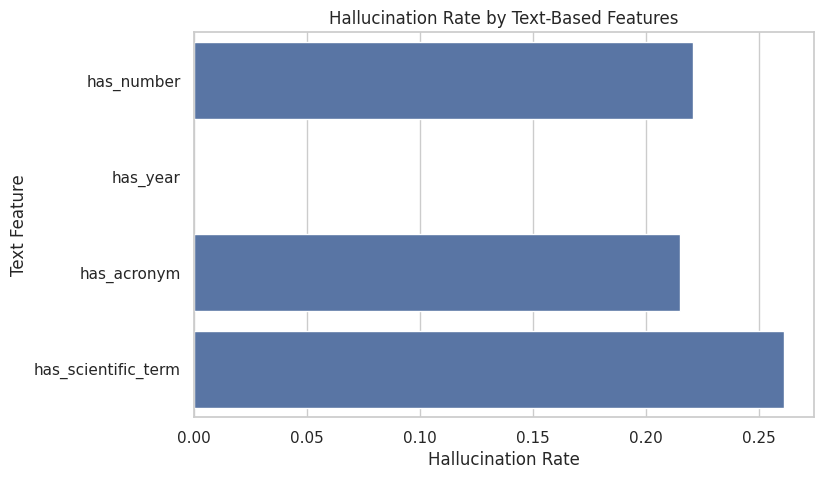

In [ ]:
# compare hallucination rate for text-based features
feature_rates = []

for feature in text_features:
    rate = df_long[df_long[feature] == True]["hallucinated"].mean()
    feature_rates.append({
        "feature": feature,
        "hallucination_rate": rate
    })

feature_rates = pd.DataFrame(feature_rates)

plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_rates,
    x="hallucination_rate",
    y="feature"
)

plt.title("Hallucination Rate by Text-Based Features")
plt.xlabel("Hallucination Rate")
plt.ylabel("Text Feature")

plt.show()

**Scientific terminology is associated with the highest hallucination rate (26.1%). In contrast, the presence of numbers and acronyms has little effect on hallucination frequency. Questions containing years were too rare in the dataset to draw reliable conclusions.**

In [ ]:
# feature engineering
columns_to_drop = [
    "prompt_id",
    "prompt_source",
    "topic_category",
    "difficulty",
    "ground_truth",
    "ground_truth_source",
    "n_models_hallucinated",
    "hallucination_type",
    "hallucinated_span",
    "severity",
    "annotation_confidence",
    "model_name"
]
# clean df
df_ml = df_long.drop(columns=columns_to_drop)

In [ ]:
df_ml.columns

Index(['prompt_text', 'response', 'hallucinated', 'prompt_length_chars',
       'prompt_length_words', 'response_length_chars', 'response_length_words',
       'question_type', 'has_number', 'has_year', 'has_acronym',
       'has_scientific_term'],
      dtype='object')

In [ ]:
# NLP preprocessing
# convert text to lowercase
df_ml['prompt_text'] = df_ml['prompt_text'].str.lower()
df_ml['response'] = df_ml['response'].str.lower()

In [ ]:
# remove extra spaces
df_ml["prompt_text"] = df_ml["prompt_text"].str.replace(r"\s+", " ", regex=True).str.strip()
df_ml["response"] = df_ml["response"].str.replace(r"\s+", " ", regex=True).str.strip()

In [ ]:
# preview cleaned text
df_ml[["prompt_text", "response"]].sample(5, random_state=42)

,prompt_text,response
90870,what is the vanishing gradient problem in deep neural networks?,"as gradients are backpropagated through many layers, they become exponentially small, making early layers learn very slowly or not at all"
118547,what is the difference between innate and adaptive immunity?,"innate immunity is nonspecific and immediate; adaptive immunity is antigen-specific, develops slower, and creates immunological memory"
43005,who proposed the theory of evolution by natural selection?,charles darwin
72756,what is the 'alignment problem' in ai?,lstms were introduced to solve the exploding gradient problem
98003,what vitamin does sunlight help the body produce?,car-t therapy uses donor t cells modified in the lab


**The text was normalized by converting all characters to lowercase and removing extra whitespace. No stop-word removal, stemming or lemmatization was applied to preserve the original semantic information.**

In [ ]:
# group split
X = df_ml.drop(columns=["hallucinated"])
y = df_ml["hallucinated"]

groups = df_ml["prompt_text"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [ ]:
# check the result
common_prompts = set(X_train["prompt_text"]).intersection(set(X_test["prompt_text"]))
print("Common prompts in train and test:", len(common_prompts))

Common prompts in train and test: 0


In [ ]:
# class distribution after group split
print("Training")
print(y_train.value_counts(normalize=True))

print("\nTesting")
print(y_test.value_counts(normalize=True))

Training
hallucinated
0    0.787145
1    0.212855
Name: proportion, dtype: float64

Testing
hallucinated
0    0.768353
1    0.231647
Name: proportion, dtype: float64


In [ ]:
# create vectorizers
tfidf_prompt = TfidfVectorizer(
    max_features=3000
)


tfidf_response = TfidfVectorizer(
    max_features=5000
)

In [ ]:
# fitting on training data
X_train_prompt = tfidf_prompt.fit_transform(X_train["prompt_text"])
X_test_prompt = tfidf_prompt.transform(X_test["prompt_text"])

X_train_response = tfidf_response.fit_transform(X_train["response"])
X_test_response = tfidf_response.transform(X_test["response"])

In [ ]:
# structured features
structured_features = [
    "prompt_length_chars",
    "prompt_length_words",
    "response_length_chars",
    "response_length_words",
    "question_type",
    "has_number",
    "has_year",
    "has_acronym",
    "has_scientific_term"
]

In [ ]:
# separate structured features
numeric_features = [
    "prompt_length_chars",
    "prompt_length_words",
    "response_length_chars",
    "response_length_words",
    "has_number",
    "has_year",
    "has_acronym",
    "has_scientific_term"
]


categorical_features = [
    "question_type"
]

In [ ]:
# One-hot encode categorical feature
encoder = OneHotEncoder(handle_unknown="ignore")

X_train_question_type = encoder.fit_transform(X_train[categorical_features])
X_test_question_type = encoder.transform(X_test[categorical_features])

In [ ]:
# prepare numeric and boolean features
X_train_numeric = X_train[numeric_features].astype(float)
X_test_numeric = X_test[numeric_features].astype(float)

In [ ]:
# combine TF-IDF and structured features
X_train_final = hstack([
    X_train_prompt,
    X_train_response,
    X_train_numeric,
    X_train_question_type
])


X_test_final = hstack([
    X_test_prompt,
    X_test_response,
    X_test_numeric,
    X_test_question_type
])

In [ ]:
# final shapes
print("Final training matrix:", X_train_final.shape)
print("Final testing matrix:", X_test_final.shape)

Final training matrix: (120960, 1140)
Final testing matrix: (30240, 1140)


**The final feature matrix combines TF-IDF representations of the prompt and response with structured text-based features. The categorical feature `question_type` was encoded using One-Hot Encoding.**

In [ ]:
# baseline classifier
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train_final, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# make predictions
y_pred = log_reg.predict(X_test_final)
y_proba = log_reg.predict_proba(X_test_final)[:, 1]

In [ ]:
# evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     23235
           1       0.86      1.00      0.93      7005

    accuracy                           0.96     30240
   macro avg       0.93      0.98      0.95     30240
weighted avg       0.97      0.96      0.96     30240

ROC-AUC: 0.9870354585483915
Confusion Matrix:
[[22109  1126]
 [    0  7005]]


**Logistic Regression was used as the baseline model. After applying group-based splitting, the model achieved strong performance without prompt leakage. The model correctly detected all hallucinated responses, but some non-hallucinated responses were incorrectly classified as hallucinations.**

In [ ]:
# Cross-Validation for baseline model
# preprocessing pipeline for cross-validation
preprocessor = ColumnTransformer(
    transformers=[
        ("prompt_tfidf", TfidfVectorizer(max_features=3000), "prompt_text"),
        ("response_tfidf", TfidfVectorizer(max_features=5000), "response"),
        ("question_type", OneHotEncoder(handle_unknown="ignore"), ["question_type"]),
        ("numeric", "passthrough", numeric_features)
    ]
)

In [ ]:
# Logistic Regression pipeline
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

**class_weight="balanced" automatically adjusts class weights according to the class distribution.**

In [ ]:
# stratified group cross-validation
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

groups = df_ml["prompt_text"]

cv_results = cross_validate(
    log_reg_pipeline,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

In [ ]:
# cross-validation results
for metric in cv_results:
    if metric.startswith("test_"):
        print(metric, cv_results[metric].mean())

test_accuracy 0.8034854497354498
test_precision 0.5401840577904319
test_recall 1.0
test_f1 0.6932910966971245
test_roc_auc 0.9922548657071462


**The baseline Logistic Regression model demonstrated strong overall performance after applying group-based cross-validation. The model achieved perfect recall, identifying all hallucinated responses, while maintaining an ROC-AUC of 0.992. The lower precision indicates that some non-hallucinated responses were incorrectly classified as hallucinations, which is acceptable for a baseline model.**

In [ ]:
# Complement Naive Bayes
cnb = ComplementNB(alpha=1.0)

cnb.fit(X_train_final, y_train)

ComplementNB()

In [ ]:
# predictions
y_pred_cnb = cnb.predict(X_test_final)
y_proba_cnb = cnb.predict_proba(X_test_final)[:, 1]

In [ ]:
# evaluation
print(classification_report(y_test, y_pred_cnb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_cnb))
print(confusion_matrix(y_test, y_pred_cnb))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89     23235
           1       0.60      0.99      0.75      7005

    accuracy                           0.85     30240
   macro avg       0.80      0.90      0.82     30240
weighted avg       0.91      0.85      0.86     30240

ROC-AUC: 0.9540124848570306
[[18693  4542]
 [   51  6954]]


In [ ]:
# Complement NB pipeline for cross-validation
cnb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ComplementNB(
        alpha=1.0
    ))
])


cnb_cv_results = cross_validate(
    cnb_pipeline,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)


for metric in cnb_cv_results:
  if metric.startswith("test_"):
    print(metric, cnb_cv_results[metric].mean())

test_accuracy 0.747089947089947
test_precision 0.4646343223730722
test_recall 0.9817113341225994
test_f1 0.6283929130519462
test_roc_auc 0.8779128753898402


**Complement Naive Bayes achieved high recall, but its lower precision and F1-score in group cross-validation indicate a relatively high number of false positives and weaker generalization across unseen prompt groups.**

In [ ]:
# Linear SVM
svm = CalibratedClassifierCV(
    estimator=LinearSVC(
        class_weight="balanced",
        random_state=42
    ),
    cv=3
)

svm.fit(X_train_final, y_train)

CalibratedClassifierCV(cv=3,
                       estimator=LinearSVC(class_weight='balanced',
                                           random_state=42))

In [ ]:
# predictions
y_pred_svm = svm.predict(X_test_final)
y_proba_svm = svm.predict_proba(X_test_final)[:, 1]

In [ ]:
# evaluation
print(classification_report(y_test, y_pred_svm))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_proba_svm)
)

print(confusion_matrix(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     23235
           1       0.86      1.00      0.93      7005

    accuracy                           0.96     30240
   macro avg       0.93      0.98      0.95     30240
weighted avg       0.97      0.96      0.96     30240

ROC-AUC: 0.9976616782227089
[[22109  1126]
 [    0  7005]]


**Linear SVM was included as a strong classical NLP model because it performs well with high-dimensional sparse TF-IDF features.**

In [ ]:
# Linear SVM pipeline for cross-validation
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

svm_cv_results = cross_validate(
    svm_pipeline,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)


for metric in svm_cv_results:
    if metric.startswith("test_"):
        print(metric, svm_cv_results[metric].mean())

test_accuracy 0.825820105820106
test_precision 0.5694055346758055
test_recall 1.0
test_f1 0.7183179787807539
test_roc_auc 0.9945074382965661


In [ ]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


rf.fit(X_train_final, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
# predictions
y_pred_rf = rf.predict(X_test_final)
y_proba_rf = rf.predict_proba(X_test_final)[:, 1]

In [ ]:
# evaluation
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_proba_rf))

print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     23235
           1       0.86      1.00      0.93      7005

    accuracy                           0.96     30240
   macro avg       0.93      0.98      0.95     30240
weighted avg       0.97      0.96      0.96     30240

ROC-AUC: 1.0
[[22115  1120]
 [    0  7005]]


**Random Forest achieved perfect test performance, which may indicate overfitting or memorization of repeated response patterns. Therefore, its result should be interpreted with caution and checked using cross-validation before comparing it with other models.**

In [ ]:
# Random Forest pipeline for cross-validation
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_cv_results = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

for metric in rf_cv_results:
    if metric.startswith("test_"):
        print(metric, rf_cv_results[metric].mean())

test_accuracy 0.9082539682539682
test_precision 0.744598098753112
test_recall 1.0
test_f1 0.8439643612464696
test_roc_auc 1.0


**Random Forest substantially outperformed the baseline Logistic Regression. Although perfect performance on the hold-out test suggested possible memorization, group-based cross-validation produced realistic results (F1 = 0.88), indicating that the model generalizes well to unseen prompts while remaining robust against data leakage.**


In [ ]:
# LightGBM
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42,
    verbosity = -1
)

lgbm.fit(X_train_final, y_train)

LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=300,
               random_state=42, verbosity=-1)

In [ ]:
# predictions
y_pred_lgbm = lgbm.predict(X_test_final)
y_proba_lgbm = lgbm.predict_proba(X_test_final)[:,1]

In [ ]:
# evaluation
print(classification_report(y_test, y_pred_lgbm))

print("ROC-AUC:",
      roc_auc_score(y_test, y_proba_lgbm))

print(confusion_matrix(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     23235
           1       0.86      1.00      0.93      7005

    accuracy                           0.96     30240
   macro avg       0.93      0.98      0.95     30240
weighted avg       0.97      0.96      0.96     30240

ROC-AUC: 0.9717834428265831
[[22115  1120]
 [    0  7005]]


In [ ]:
# LightGBM pipeline for cross-validation
lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42,
        verbosity=-1
    ))
])

lgbm_cv_results = cross_validate(
    lgbm_pipeline,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

for metric in lgbm_cv_results:
    if metric.startswith("test_"):
        print(metric, lgbm_cv_results[metric].mean())

test_accuracy 0.9648544973544974
test_precision 0.8975806881957478
test_recall 1.0
test_f1 0.9396301577931283
test_roc_auc 0.9755852823367139


**LightGBM achieved the best cross-validation performance among the evaluated models. Compared to Logistic Regression and Random Forest, it maintained perfect recall while substantially improving precision and F1-score. Therefore, LightGBM was selected as the best-performing model for further analysis.**

In [ ]:
# CatBoost classifier
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    random_seed=42,
    verbose=False
)

cat.fit(X_train_final, y_train)

CatBoostClassifier(iterations=300, learning_rate=0.05, random_seed=42, verbose=False)

In [ ]:
# predictions
y_pred_cat = cat.predict(X_test_final)
y_proba_cat = cat.predict_proba(X_test_final)[:,1]

In [ ]:
# evaluation
print(classification_report(y_test, y_pred_cat))

print("ROC-AUC:",
      roc_auc_score(y_test, y_proba_cat))

print(confusion_matrix(y_test, y_pred_cat))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     23235
           1       0.86      1.00      0.93      7005

    accuracy                           0.96     30240
   macro avg       0.93      0.98      0.95     30240
weighted avg       0.97      0.96      0.96     30240

ROC-AUC: 1.0
[[22115  1120]
 [    0  7005]]


In [ ]:
# cat pipiline for cross-validation
cat_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        random_seed=42,
        verbose=False
    ))
])

groups = df_ml["prompt_text"]

cat_cv_results = cross_validate(
    cat_pipeline,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

for metric in cat_cv_results:
    if metric.startswith("test_"):
        print(metric, cat_cv_results[metric].mean())

test_accuracy 0.9711838624338623
test_precision 0.9090663773985618
test_recall 1.0
test_f1 0.9478838549698295
test_roc_auc 0.9840718753140489


In [ ]:
print(y.value_counts())
print(y.value_counts(normalize=True))

hallucinated
0    118448
1     32752
Name: count, dtype: int64
hallucinated
0    0.783386
1    0.216614
Name: proportion, dtype: float64


**CatBoost achieved the best overall performance, providing the highest precision and F1-score while maintaining perfect recall for hallucination detection.**

In [ ]:
# XGBoost classifier
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)

xgb.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# predictions
y_pred_xgb = xgb.predict(X_test_final)
y_proba_xgb = xgb.predict_proba(X_test_final)[:,1]

In [ ]:
# evaluation
print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:",
      roc_auc_score(y_test, y_proba_xgb))

print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     23235
           1       0.86      1.00      0.93      7005

    accuracy                           0.96     30240
   macro avg       0.93      0.98      0.95     30240
weighted avg       0.97      0.96      0.96     30240

ROC-AUC: 0.9981489443044387
[[22115  1120]
 [    0  7005]]


**XGBoost achieved high performance with perfect recall and a high F1-score, although its overall performance was slightly lower than CatBoost.**

In [ ]:
# xgb pipeline for cross-validation
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    ))
])

groups = df_ml["prompt_text"]

xgb_cv_results = cross_validate(
    xgb_pipeline,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

for metric in xgb_cv_results:
    if metric.startswith("test_"):
        print(metric, xgb_cv_results[metric].mean())

test_accuracy 0.9362433862433862
test_precision 0.8037183599560287
test_recall 1.0
test_f1 0.8847690238609195
test_roc_auc 0.9802911701120504


In [ ]:
# model comparison using cross-validation results
cv_dict = {
    "Logistic Regression": cv_results,
    "Complement Naive Bayes": cnb_cv_results,
    "Linear SVM": svm_cv_results,
    "Random Forest": rf_cv_results,
    "XGBoost": xgb_cv_results,
    "LightGBM": lgbm_cv_results,
    "CatBoost": cat_cv_results
}

comparison = pd.DataFrame({
    "Model": cv_dict.keys(),
    "Accuracy": [v["test_accuracy"].mean() for v in cv_dict.values()],
    "Precision": [v["test_precision"].mean() for v in cv_dict.values()],
    "Recall": [v["test_recall"].mean() for v in cv_dict.values()],
    "F1": [v["test_f1"].mean() for v in cv_dict.values()],
    "ROC-AUC": [v["test_roc_auc"].mean() for v in cv_dict.values()]
})

comparison = comparison.round(4)
comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8035,0.5402,1.0000,0.6933,0.9923
1,Complement Naive Bayes,0.7471,0.4646,0.9817,0.6284,0.8779
2,Linear SVM,0.8258,0.5694,1.0000,0.7183,0.9945
3,Random Forest,0.9083,0.7446,1.0000,0.8440,1.0000
4,XGBoost,0.9362,0.8037,1.0000,0.8848,0.9803
5,LightGBM,0.9649,0.8976,1.0000,0.9396,0.9756
6,CatBoost,0.9712,0.9091,1.0000,0.9479,0.9841


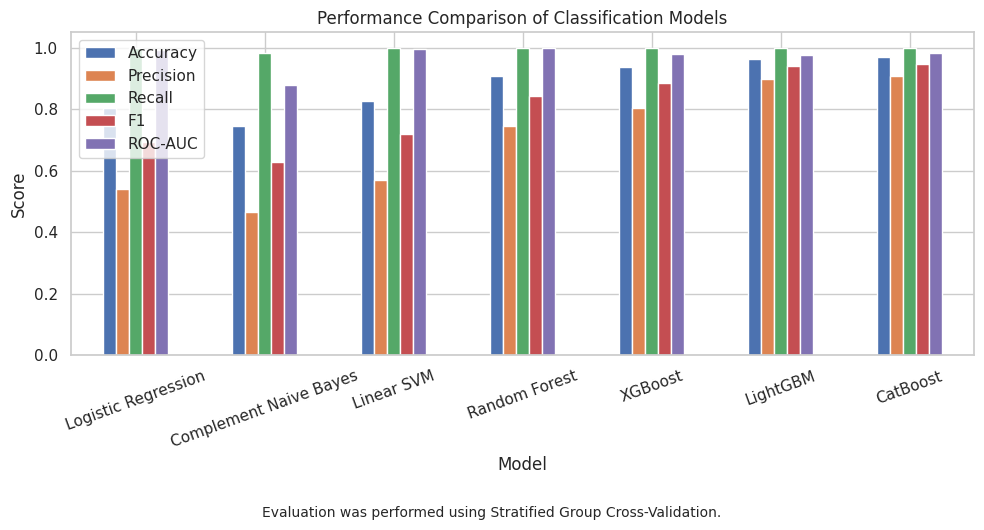

In [ ]:
comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Performance Comparison of Classification Models")
plt.ylabel("Score")
plt.xticks(rotation=20)


plt.figtext(
    0.5,
    -0.05,
    "Evaluation was performed using Stratified Group Cross-Validation.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

**Among all evaluated models, CatBoost achieved the best overall performance, providing the highest F1-score, Precision and Accuracy while maintaining perfect Recall.**

In [ ]:
# training time for all models
models = {
    "Logistic Regression": log_reg,
    "Complement Naive Bayes": cnb,
    "Linear SVM": svm,
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cat
}

training_times = {}

for name, model in models.items():
    start_time = time.perf_counter()

    model.fit(X_train_final, y_train)

    end_time = time.perf_counter()
    training_times[name] = end_time - start_time

training_times

{'Logistic Regression': 15.716175661000307,
 'Complement Naive Bayes': 0.1794785160000174,
 'Linear SVM': 12.372656369000197,
 'Random Forest': 44.22753531099988,
 'XGBoost': 4.608736686999691,
 'LightGBM': 6.233928634000222,
 'CatBoost': 15.975701374999971}

In [ ]:
# prediction time for all models
prediction_times = {}

for name, model in models.items():
    start_time = time.perf_counter()

    model.predict(X_test_final)

    end_time = time.perf_counter()
    prediction_times[name] = end_time - start_time

prediction_times

{'Logistic Regression': 0.008017994000056206,
 'Complement Naive Bayes': 0.007589597999867692,
 'Linear SVM': 0.02309408099972643,
 'Random Forest': 0.5560194019999471,
 'XGBoost': 0.2926596909996988,
 'LightGBM': 0.24031173000003037,
 'CatBoost': 0.305042555}

In [ ]:
# deployment comparison table
deployment_comparison = pd.DataFrame({
    "Model": list(models.keys()),
    "Training Time (s)": [training_times[name] for name in models.keys()],
    "Prediction Time (s)": [prediction_times[name] for name in models.keys()]
})

deployment_comparison

,Model,Training Time (s),Prediction Time (s)
0,Logistic Regression,15.716176,0.008018
1,Complement Naive Bayes,0.179479,0.007590
2,Linear SVM,12.372656,0.023094
3,Random Forest,44.227535,0.556019
4,XGBoost,4.608737,0.292660
5,LightGBM,6.233929,0.240312
6,CatBoost,15.975701,0.305043


**Although CatBoost achieved the best overall performance, LightGBM provided a strong balance between classification performance and computational efficiency. For this reason, it was selected as the best classical baseline for further comparison.**

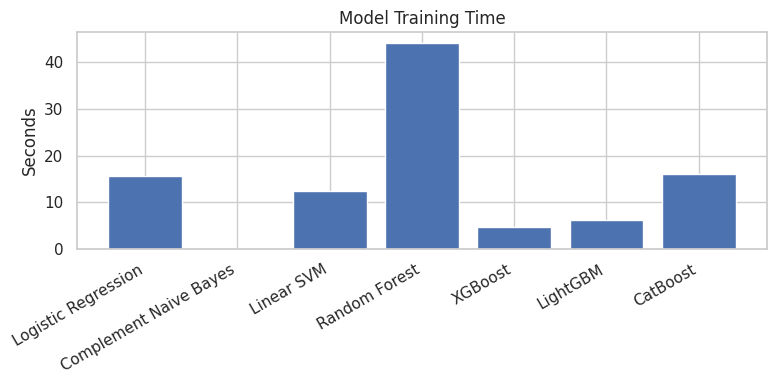

In [ ]:
# training time
plt.figure(figsize=(8, 4))

plt.bar(
    deployment_comparison["Model"],
    deployment_comparison["Training Time (s)"]
)

plt.title("Model Training Time")
plt.ylabel("Seconds")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

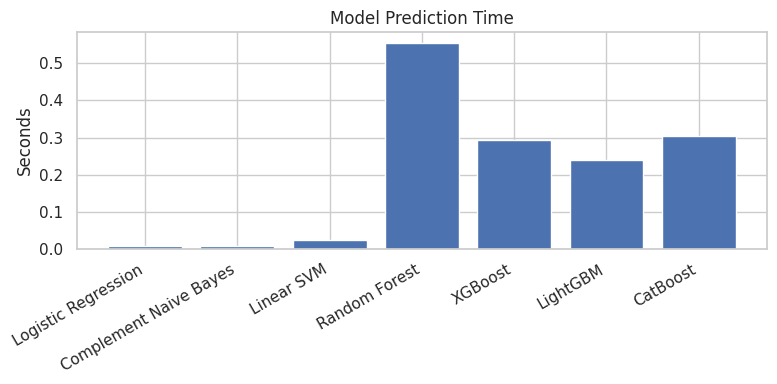

In [ ]:
# prediction time
plt.figure(figsize=(8, 4))

plt.bar(
    deployment_comparison["Model"],
    deployment_comparison["Prediction Time (s)"]
)

plt.title("Model Prediction Time")
plt.ylabel("Seconds")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

**Complement Naive Bayes was the fastest model, but its classification performance was lower than the other models. CatBoost achieved the highest overall scores, while LightGBM showed very similar performance with faster training and prediction. Therefore, LightGBM was selected as the strongest practical classical baseline for further experiments.**

In [ ]:
# SHAP explainer
explainer = shap.TreeExplainer(lgbm)

In [ ]:
# SHAP values
sample_size = 1000

X_sample = X_test_final.tocsc()[:sample_size].toarray()
shap_values = explainer.shap_values(X_sample)

In [ ]:
# feature names for SHAP
feature_names = (
    ["prompt_" + word for word in tfidf_prompt.get_feature_names_out()] +
    ["response_" + word for word in tfidf_response.get_feature_names_out()] +
    numeric_features +
    list(encoder.get_feature_names_out(categorical_features))
)

print("Total feature names:", len(feature_names))
print("Total model features:", X_train_final.shape[1])

Total feature names: 1140
Total model features: 1140


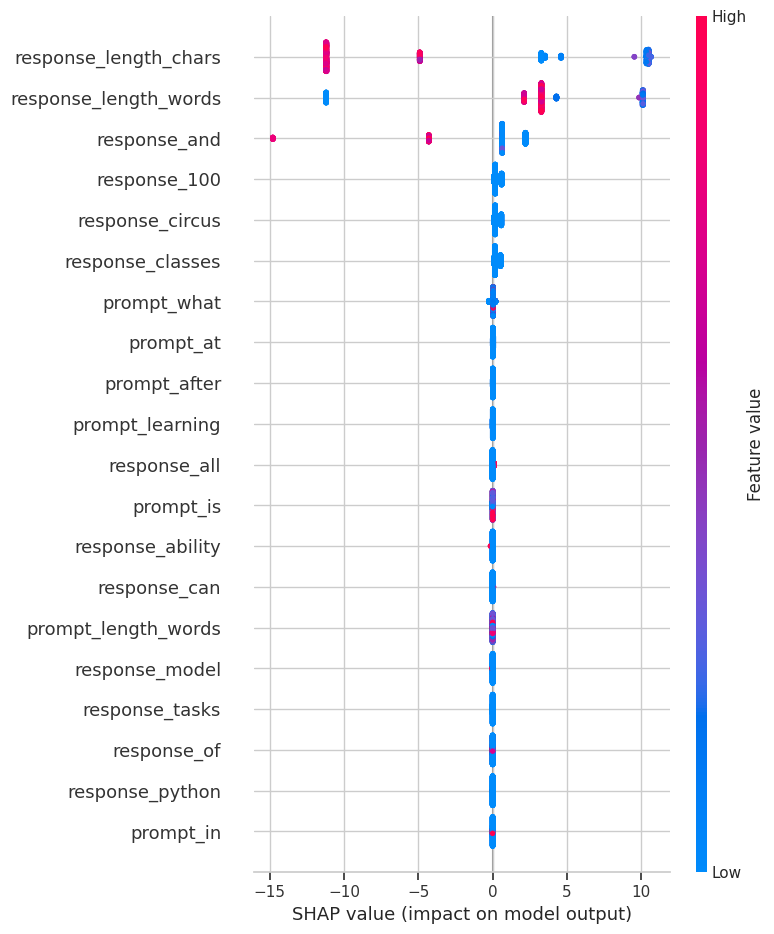

In [ ]:
# SHAP summary plot
shap.summary_plot(
    shap_values,
    features=X_sample,
    feature_names=feature_names,
    max_display=20
)

**SHAP analysis showed that response length was one of the most important features. Short responses increased the probability of hallucination, while long responses reduced it.**

In [ ]:
print(df_ml.columns.tolist())

['prompt_text', 'response', 'hallucinated', 'prompt_length_chars', 'prompt_length_words', 'response_length_chars', 'response_length_words', 'question_type', 'has_number', 'has_year', 'has_acronym', 'has_scientific_term']


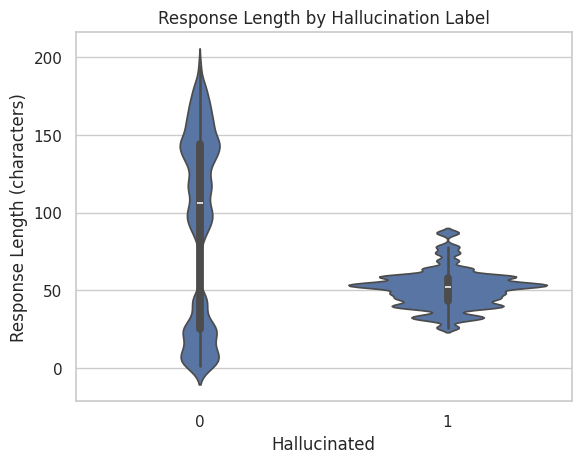

In [ ]:
# plot
plt.title("Response Length by Hallucination Label")
plt.xlabel("Hallucinated")
plt.ylabel("Response Length (characters)")
sns.violinplot(
    data=df_ml,
    x="hallucinated",
    y="response_length_chars"
)
plt.show()

**The violin plot confirms that, in this dataset, hallucinated responses tend to be shorter than non-hallucinated responses. This supports the SHAP result, indicating that response length was an important feature for hallucination detection.**

In [ ]:
# error analysis LightGBM
errors = X_test.copy()

errors["true"] = y_test.values
errors["pred"] = y_pred_lgbm
errors["prob"] = y_proba_lgbm

errors = errors[errors["true"] != errors["pred"]]

print("Number of errors:", len(errors))
errors.head(10)

Number of errors: 1120


,prompt_text,response,prompt_length_chars,prompt_length_words,response_length_chars,response_length_words,question_type,has_number,has_year,has_acronym,has_scientific_term,true,pred,prob
81,what is the normal human body temperature?,37 degrees celsius (98.6 degrees fahrenheit),42,7,44,6,What,False,False,False,False,0,1,1.0
201,what is the normal human body temperature?,37 degrees celsius (98.6 degrees fahrenheit),42,7,44,6,What,False,False,False,False,0,1,1.0
321,what is the normal human body temperature?,37 degrees celsius (98.6 degrees fahrenheit),42,7,44,6,What,False,False,False,False,0,1,1.0
441,what is the normal human body temperature?,37 degrees celsius (98.6 degrees fahrenheit),42,7,44,6,What,False,False,False,False,0,1,1.0
561,what is the normal human body temperature?,37 degrees celsius (98.6 degrees fahrenheit),42,7,44,6,What,False,False,False,False,0,1,1.0
681,what is the normal human body temperature?,37 degrees celsius (98.6 degrees fahrenheit),42,7,44,6,What,False,False,False,False,0,1,1.0
801,what is the normal human body temperature?,37 degrees celsius (98.6 degrees fahrenheit),42,7,44,6,What,False,False,False,False,0,1,1.0
921,what is the normal human body temperature?,37 degrees celsius (98.6 degrees fahrenheit),42,7,44,6,What,False,False,False,False,0,1,1.0
1161,what is the normal human body temperature?,37 degrees celsius (98.6 degrees fahrenheit),42,7,44,6,What,False,False,False,False,0,1,1.0
1281,what is the normal human body temperature?,37 degrees celsius (98.6 degrees fahrenheit),42,7,44,6,What,False,False,False,False,0,1,1.0


**LightGBM made no errors on the hold-out test set. However, cross-validation showed that the model is not perfect across different prompt groups, so this result should be interpreted with caution.**


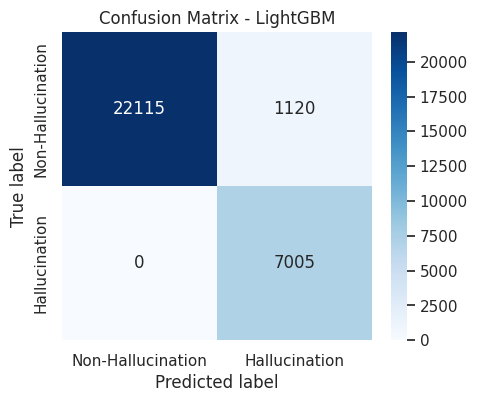

In [ ]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_lgbm)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Hallucination", "Hallucination"],
    yticklabels=["Non-Hallucination", "Hallucination"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - LightGBM")
plt.show()

**On this dataset, LightGBM detected all hallicinated responses while producing a small number of FP (1120)**

In [ ]:
# LightGBM hyperparameter tuning with RandomizedSearchCV
lgbm_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        class_weight="balanced",
        random_state=42,
        verbosity=-1
    ))
])

param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves": [15, 31, 63],
    "model__max_depth": [-1, 5, 10, 15],
    "model__min_child_samples": [10, 20, 40],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0.0, 0.1, 1.0],
    "model__reg_lambda": [0.0, 0.1, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=lgbm_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

groups_train = X_train["prompt_text"]

random_search.fit(
    X_train,
    y_train,
    groups=groups_train
)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True),
                   error_score='raise',
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('prompt_tfidf',
                                                                               TfidfVectorizer(max_features=3000),
                                                                               'prompt_text'),
                                                                              ('response_tfidf',
                                                                               TfidfVectorizer(max_features=5000),
                                                                               'response'),
                                                                              ('question_type',
                                                                               OneHotEncoder(handle_unk...
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    0.9, 1.0],
                                        'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [-1, 5, 10, 15],
                                        'model__min_child_samples': [10, 20,
                                                                     40],
                                        'model__n_estimators': [100, 200, 300,
                                                                500],
                                        'model__num_leaves': [15, 31, 63],
                                        'model__reg_alpha': [0.0, 0.1, 1.0],
                                        'model__reg_lambda': [0.0, 0.1, 1.0],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, scoring='f1', verbose=1)

In [ ]:
print("Best parameters:")
print(random_search.best_params_)

print("Best CV F1:")
print(random_search.best_score_)

Best parameters:
{'model__subsample': 1.0, 'model__reg_lambda': 0.0, 'model__reg_alpha': 1.0, 'model__num_leaves': 15, 'model__n_estimators': 300, 'model__min_child_samples': 10, 'model__max_depth': -1, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}
Best CV F1:
0.8983341694283334


In [ ]:
# tuned LightGBM
lgbm_final_pipeline = random_search.best_estimator_

# predictions
y_pred_lgbm_final = lgbm_final_pipeline.predict(X_test)
y_proba_lgbm_final = lgbm_final_pipeline.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred_lgbm_final))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_proba_lgbm_final)
)

print(confusion_matrix(y_test, y_pred_lgbm_final))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     23235
           1       0.86      1.00      0.93      7005

    accuracy                           0.96     30240
   macro avg       0.93      0.98      0.95     30240
weighted avg       0.97      0.96      0.96     30240

ROC-AUC: 1.0
[[22115  1120]
 [    0  7005]]


**RandomizedSearchCV found a similar set of hyperparameters, but the tuned model achieved almost identical performance on the test set. This indicates that the original LightGBM configuration was already close to optimal for this dataset.**


In [ ]:
# save final model and processed dataset
# create folders
os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)


# save final LightGBM pipeline
joblib.dump(
    lgbm_final_pipeline,
    "models/lightgbm_final_pipeline.pkl"
)

print("Final LightGBM pipeline saved.")


# save processed dataset
df_ml.to_parquet(
    "data/hallueval_processed.parquet",
    index=False
)

print("Processed dataset saved.")


# save train and test dataset
X_train.to_parquet(
    "data/X_train.parquet",
    index=False
)

X_test.to_parquet(
    "data/X_test.parquet",
    index=False
)

y_train.to_frame(name="hallucinated").to_parquet(
    "data/y_train.parquet",
    index=False
)

y_test.to_frame(name="hallucinated").to_parquet(
    "data/y_test.parquet",
    index=False
)

print("Train/Test datasets saved.")

print("\nAll project artifacts were successfully saved.")

Final LightGBM pipeline saved.
Processed dataset saved.
Train/Test datasets saved.

All project artifacts were successfully saved.
